<a href="https://colab.research.google.com/github/shehzadtm/KhuramFiles/blob/main/IsharesSectorRotationPlots.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

SECTOR ROTATION ANALYSIS - ETF PERFORMANCE WITH ROTATION SIGNALS
Data as of: 2026-08-31
Ticker   ETF Name                                      TRL P/E    Price      20D%       50D%       1Y%        YTD%       20D RS%    50D RS%    1Y RS%     MFI      Volume       Rotation Signal               
SOXX     iShares Semiconductor ETF                     40.99      $511.04    0.66       -20.08     103.30     63.09      -0.57      -22.20     70.10      43.18    Decreasing   ⚖️ Mixed / Consolidating      
IYE      iShares U.S. Energy ETF                       21.98      $67.59     8.20       19.06      45.04      40.63      6.87       15.91      21.36      61.95    Decreasing   🔥 Late-Stage Blow-Off         
IGE      iShares North American Natural Resources ETF  21.14      $65.87     10.15      14.66      41.27      29.99      8.80       11.62      18.20      63.78    Increasing   🔥 Late-Stage Blow-Off         
IYZ      iShares U.S. Telecommunications ETF           19.34      $43.12     2.99   

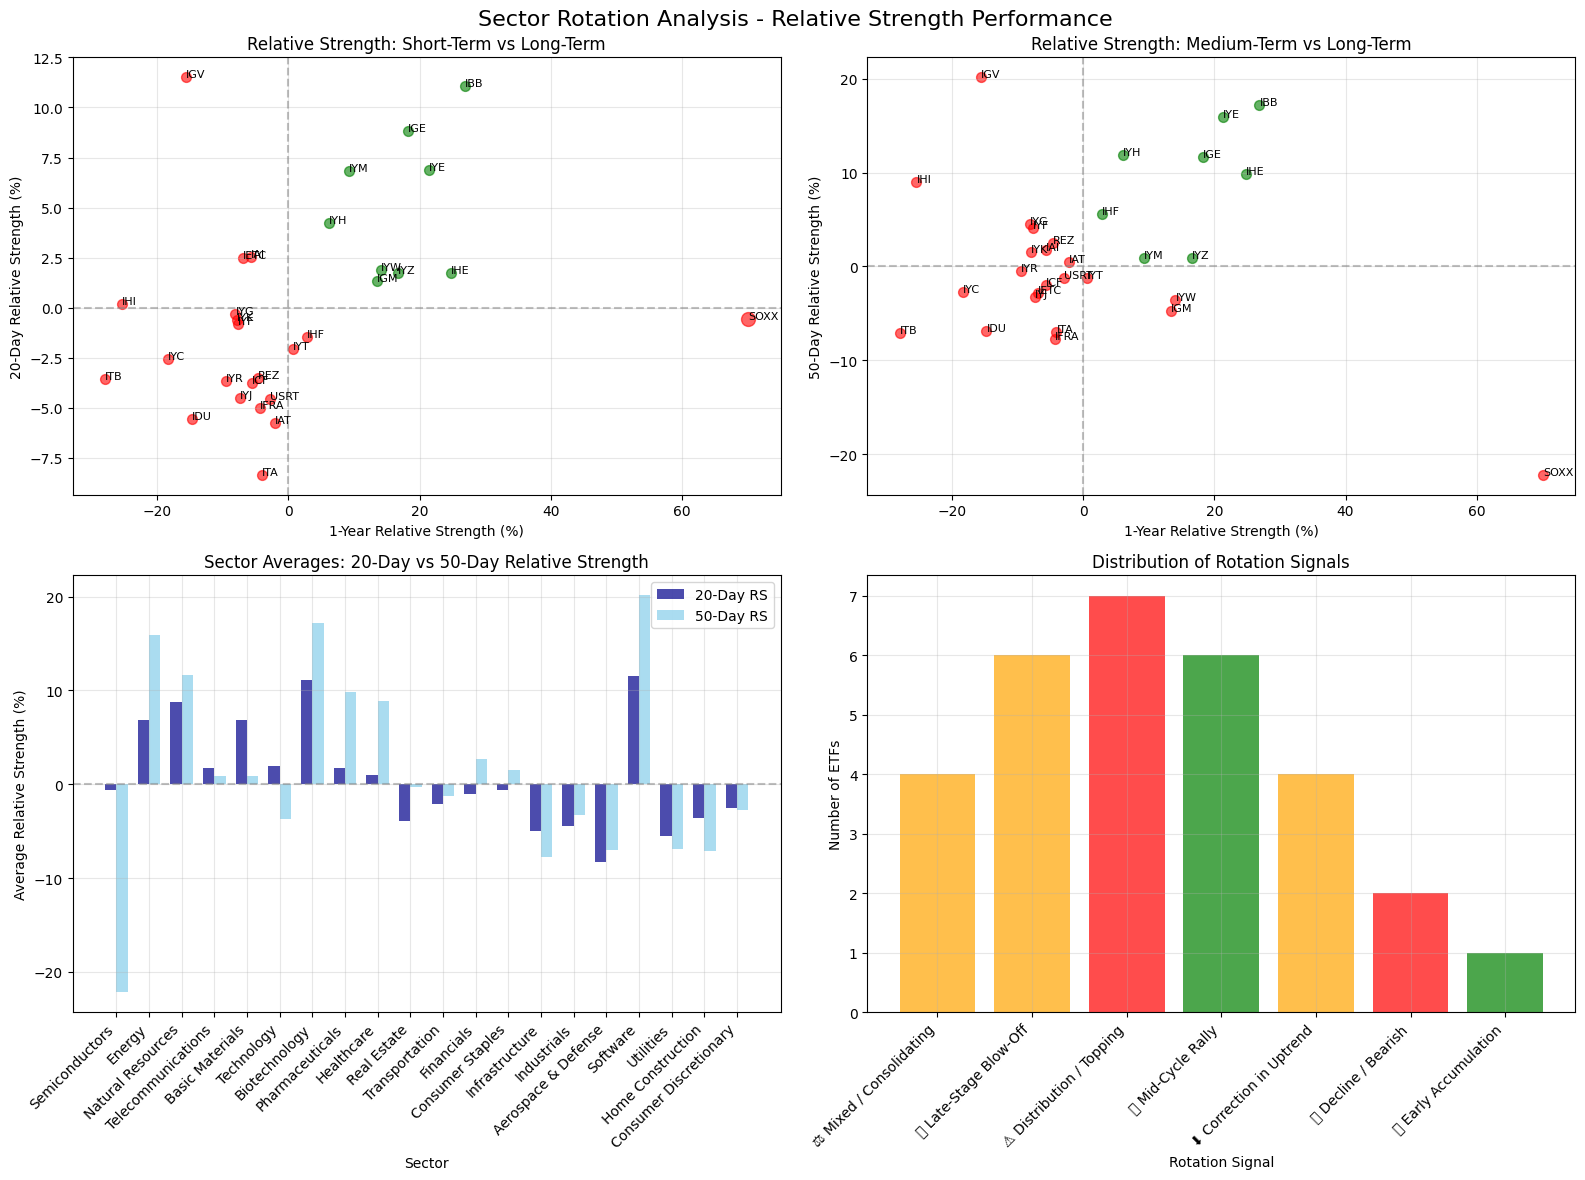


✅ Visualization saved as 'sector_rotation_analysis.png'

ANALYSIS COMPLETE


In [18]:
import yfinance as yf
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import warnings
from collections import Counter
warnings.filterwarnings('ignore')

# List of ETFs from your table
etfs = [
    "SOXX", "IYE", "IGE", "IYZ", "IYM", "IYW", "IGM", "IBB",
    "IHE", "IHF", "USRT", "IYT", "REZ", "ICF", "IAT", "IYK",
    "IFRA", "IYH", "IYR", "IYJ", "IAI", "ITA", "IYF", "IETC",
    "IYG", "IGV", "IDU", "ITB", "IYC", "IHI"
]

# ETF Name mapping
etf_names = {
    "SOXX": "iShares Semiconductor ETF",
    "IYE": "iShares U.S. Energy ETF",
    "IGE": "iShares North American Natural Resources ETF",
    "IYZ": "iShares U.S. Telecommunications ETF",
    "IYM": "iShares U.S. Basic Materials ETF",
    "IYW": "iShares U.S. Technology ETF",
    "IGM": "iShares Expanded Tech Sector ETF",
    "IBB": "iShares Biotechnology ETF",
    "IHE": "iShares U.S. Pharmaceuticals ETF",
    "IHF": "iShares U.S. Healthcare Providers ETF",
    "USRT": "iShares Core U.S. REIT ETF",
    "IYT": "iShares U.S. Transportation ETF",
    "REZ": "iShares Residential and Multisector Real Estate ETF",
    "ICF": "iShares Select U.S. REIT ETF",
    "IAT": "iShares U.S. Regional Banks ETF",
    "IYK": "iShares U.S. Consumer Staples ETF",
    "IFRA": "iShares U.S. Infrastructure ETF",
    "IYH": "iShares U.S. Healthcare ETF",
    "IYR": "iShares U.S. Real Estate ETF",
    "IYJ": "iShares U.S. Industrials ETF",
    "IAI": "iShares U.S. Broker-Dealers & Securities Exchanges ETF",
    "ITA": "iShares U.S. Aerospace & Defense ETF",
    "IYF": "iShares U.S. Financials ETF",
    "IETC": "iShares U.S. Tech Independence Focused ETF",
    "IYG": "iShares U.S. Financial Services ETF",
    "IGV": "iShares Expanded Tech-Software Sector ETF",
    "IDU": "iShares U.S. Utilities ETF",
    "ITB": "iShares U.S. Home Construction ETF",
    "IYC": "iShares U.S. Consumer Discretionary ETF",
    "IHI": "iShares U.S. Medical Devices ETF"
}

# Sector mapping for rotation analysis
sector_mapping = {
    "Semiconductors": ["SOXX"],
    "Energy": ["IYE"],
    "Natural Resources": ["IGE"],
    "Telecommunications": ["IYZ"],
    "Basic Materials": ["IYM"],
    "Technology": ["IYW", "IGM", "IETC"],
    "Biotechnology": ["IBB"],
    "Pharmaceuticals": ["IHE"],
    "Healthcare": ["IHF", "IYH", "IHI"],
    "Real Estate": ["USRT", "REZ", "ICF", "IYR"],
    "Transportation": ["IYT"],
    "Financials": ["IAT", "IAI", "IYF", "IYG"],
    "Consumer Staples": ["IYK"],
    "Infrastructure": ["IFRA"],
    "Industrials": ["IYJ"],
    "Aerospace & Defense": ["ITA"],
    "Software": ["IGV"],
    "Utilities": ["IDU"],
    "Home Construction": ["ITB"],
    "Consumer Discretionary": ["IYC"]
}

def get_sector(ticker):
    """
    Get sector for a ticker
    """
    for sector, tickers in sector_mapping.items():
        if ticker in tickers:
            return sector
    return "Other"

# Main execution
print("=" * 180)
print("SECTOR ROTATION ANALYSIS - ETF PERFORMANCE WITH ROTATION SIGNALS")
print("=" * 180)
print(f"Data as of: {datetime.now().strftime('%Y-%m-%d')}")
print("=" * 180)

# Header
print(f"{'Ticker':<8} {'ETF Name':<45} {'TRL P/E':<10} {'Price':<10} {'20D%':<10} {'50D%':<10} {'1Y%':<10} {'YTD%':<10} {'20D RS%':<10} {'50D RS%':<10} {'1Y RS%':<10} {'MFI':<8} {'Volume':<12} {'Rotation Signal':<30}")
print("=" * 180)

results = []
for ticker in etfs:
    # Fetch additional info for Trailing P/E
    trl_pe = np.nan
    try:
        ticker_info = yf.Ticker(ticker).info
        trl_pe = ticker_info.get('trailingPE', np.nan) # Changed to trailingPE
    except Exception as e:
        # print(f"Warning: Could not fetch info for {ticker}: {e}")
        pass # Suppress warning for now, as not all tickers have 'trailingPE'

    data = calculate_returns(ticker)

    if data:
        name = etf_names.get(ticker, ticker)
        sector = get_sector(ticker) # Keep sector for internal grouping/summary
        price = f"${data['price']:.2f}" if data['price'] else "N/A"

        # Format returns
        r20 = f"{data['20d']:.2f}" if not np.isnan(data['20d']) else "N/A"
        r50 = f"{data['50d']:.2f}" if not np.isnan(data['50d']) else "N/A"
        r1y = f"{data['1y']:.2f}" if not np.isnan(data['1y']) else "N/A"
        rytd = f"{data['ytd']:.2f}" if not np.isnan(data['ytd']) else "N/A"

        # Format RS returns
        rs20 = f"{data.get('20d_rs', np.nan):.2f}" if not np.isnan(data.get('20d_rs', np.nan)) else "N/A"
        rs50 = f"{data.get('50d_rs', np.nan):.2f}" if not np.isnan(data.get('50d_rs', np.nan)) else "N/A"
        rs1y = f"{data.get('1y_rs', np.nan):.2f}" if not np.isnan(data.get('1y_rs', np.nan)) else "N/A"

        # Format MFI
        mfi = f"{data.get('mfi', np.nan):.2f}" if not np.isnan(data.get('mfi', np.nan)) else "N/A"

        # Format TRL P/E
        formatted_trl_pe = f"{trl_pe:.2f}" if not np.isnan(trl_pe) else "N/A" # Changed to formatted_trl_pe

        signal = data['signal']
        volume = data.get('volume_trend', 'N/A')

        print(f"{ticker:<8} {name:<45} {formatted_trl_pe:<10} {price:<10} {r20:<10} {r50:<10} {r1y:<10} {rytd:<10} {rs20:<10} {rs50:<10} {rs1y:<10} {mfi:<8} {volume:<12} {signal:<30}") # Changed to formatted_trl_pe

        results.append({
            'Ticker': ticker,
            'Name': name,
            'Sector': sector, # Kept for sector_summary calculations
            'TRL_PE': trl_pe, # Changed to TRL_PE
            'Price': data['price'],
            '20D': data['20d'],
            '50D': data['50d'],
            '1Y': data['1y'],
            'YTD': data['ytd'],
            '20D_RS': data.get('20d_rs', np.nan),
            '50D_RS': data.get('50d_rs', np.nan),
            '1Y_RS': data.get('1y_rs', np.nan),
            'MFI': data.get('mfi', np.nan),
            'Volume_Trend': volume,
            'Rotation_Signal': signal,
            'Date': data['date']
        })

print("=" * 180)

# Sector Summary with Rotation Analysis
print("\n" + "=" * 100)
print("SECTOR SUMMARY WITH ROTATION ANALYSIS")
print("=" * 100)

# Group by sector
sector_summary = {}
for result in results:
    sector = result['Sector']
    if sector not in sector_summary:
        sector_summary[sector] = {
            'tickers': [],
            '20d': [],
            '50d': [],
            '1y': [],
            '20d_rs': [],
            '50d_rs': [],
            '1y_rs': [],
            'mfi': [],
            'signals': []
        }
    sector_summary[sector]['tickers'].append(result['Ticker'])
    if not np.isnan(result['20D']):
        sector_summary[sector]['20d'].append(result['20D'])
    if not np.isnan(result['50D']):
        sector_summary[sector]['50d'].append(result['50D'])
    if not np.isnan(result['1Y']):
        sector_summary[sector]['1y'].append(result['1Y'])
    if not np.isnan(result.get('20D_RS', np.nan)):
        sector_summary[sector]['20d_rs'].append(result['20D_RS'])
    if not np.isnan(result.get('50D_RS', np.nan)):
        sector_summary[sector]['50d_rs'].append(result['50D_RS'])
    if not np.isnan(result.get('1Y_RS', np.nan)):
        sector_summary[sector]['1y_rs'].append(result['1Y_RS'])
    if not np.isnan(result.get('MFI', np.nan)):
        sector_summary[sector]['mfi'].append(result['MFI'])
    sector_summary[sector]['signals'].append(result['Rotation_Signal'])

print(f"{'Sector':<25} {'Avg 20D%':<12} {'Avg 50D%':<12} {'Avg 1Y%':<12} {'Avg 20D RS%':<12} {'Avg 50D RS%':<12} {'Avg 1Y RS%':<12} {'Avg MFI':<10} {'Primary Signal':<35} {'Tickers':<20}")
print("-" * 190)

for sector, data in sector_summary.items():
    avg_20d = np.mean(data['20d']) if data['20d'] else np.nan
    avg_50d = np.mean(data['50d']) if data['50d'] else np.nan
    avg_1y = np.mean(data['1y']) if data['1y'] else np.nan
    avg_20d_rs = np.mean(data['20d_rs']) if data['20d_rs'] else np.nan
    avg_50d_rs = np.mean(data['50d_rs']) if data['50d_rs'] else np.nan
    avg_1y_rs = np.mean(data['1y_rs']) if data['1y_rs'] else np.nan
    avg_mfi = np.mean(data['mfi']) if data['mfi'] else np.nan

    # Get most common signal
    signal_counts = Counter(data['signals'])
    primary_signal = signal_counts.most_common(1)[0][0] if signal_counts else "N/A"

    tickers_str = ", ".join(data['tickers'])

    print(f"{sector:<25} {avg_20d:>6.2f}% {avg_50d:>6.2f}% {avg_1y:>6.2f}% {avg_20d_rs:>8.2f}% {avg_50d_rs:>8.2f}% {avg_1y_rs:>8.2f}% {avg_mfi:>8.2f} {primary_signal:<35} {tickers_str:<20}")

print("=" * 100)

# Rotation Recommendations
print("\n" + "=" * 100)
print("📊 ROTATION RECOMMENDATIONS")
print("=" * 100)

# Identify rotation candidates
early_accumulation = [r for r in results if r['Rotation_Signal'] == "🔄 Early Accumulation"]
late_stage = [r for r in results if r['Rotation_Signal'] == "🔥 Late-Stage Blow-Off"]
distribution = [r for r in results if r['Rotation_Signal'] == "⚠️ Distribution / Topping"]
decline = [r for r in results if r['Rotation_Signal'] == "📉 Decline / Bearish"]

if early_accumulation:
    print("\n🔄 EARLY ACCUMULATION (Potential Buys - Money flowing in)")
    for r in early_accumulation:
        print(f" • {r['Ticker']} ({r['Name']}) - 20D: {r['20D']:.2f}% | 50D: {r['50D']:.2f}% | 1Y: {r['1Y']:.2f}% | 20D RS: {r['20D_RS']:.2f}% | 1Y RS: {r['1Y_RS']:.2f}% | MFI: {r['MFI']:.2f}")

if late_stage:
    print("\n🔥 LATE-STAGE BLOW-OFF (Consider Taking Profits)")
    for r in late_stage:
        print(f" • {r['Ticker']} ({r['Name']}) - 20D: {r['20D']:.2f}% | 50D: {r['50D']:.2f}% | 1Y: {r['1Y']:.2f}% | 20D RS: {r['20D_RS']:.2f}% | 1Y RS: {r['1Y_RS']:.2f}% | MFI: {r['MFI']:.2f}")

if distribution:
    print("\n⚠️ DISTRIBUTION / TOPPING (Avoid or Short)")
    for r in distribution:
        print(f" • {r['Ticker']} ({r['Name']}) - 20D: {r['20D']:.2f}% | 50D: {r['50D']:.2f}% | 1Y: {r['1Y']:.2f}% | 20D RS: {r['20D_RS']:.2f}% | 1Y RS: {r['1Y_RS']:.2f}% | MFI: {r['MFI']:.2f}")

if decline:
    print("\n📉 DECLINE / BEARISH (Stay Away)")
    for r in decline:
        print(f" • {r['Ticker']} ({r['Name']}) - 20D: {r['20D']:.2f}% | 50D: {r['50D']:.2f}% | 1Y: {r['1Y']:.2f}% | 20D RS: {r['20D_RS']:.2f}% | 1Y RS: {r['1Y_RS']:.2f}% | MFI: {r['MFI']:.2f}")

# Export to CSV
df_results = pd.DataFrame(results)
# Define columns to export, excluding 'Sector' and including 'TRL_PE'
export_columns = [
    'Ticker', 'Name', 'TRL_PE', 'Price', '20D', '50D', '1Y', 'YTD',
    '20D_RS', '50D_RS', '1Y_RS', 'MFI', 'Volume_Trend', 'Rotation_Signal', 'Date'
]
df_results[export_columns].to_csv('etf_rotation_analysis.csv', index=False)
print("\n✅ Results exported to 'etf_rotation_analysis.csv'")

# Visualization
print("\n📊 Generating visualization...")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Sector Rotation Analysis - Relative Strength Performance', fontsize=16)

# Plot 1: 20-Day RS vs 1-Year RS
ax1 = axes[0, 0]
for result in results:
    if not np.isnan(result['1Y_RS']) and not np.isnan(result['20D_RS']):
        color = 'green' if result['20D_RS'] > 0 and result['1Y_RS'] > 0 else 'red'
        size = 100 if result['1Y_RS'] > 30 else 50
        ax1.scatter(result['1Y_RS'], result['20D_RS'], c=color, s=size, alpha=0.6)
        ax1.annotate(result['Ticker'], (result['1Y_RS'], result['20D_RS']), fontsize=8)

ax1.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax1.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
ax1.set_xlabel('1-Year Relative Strength (%)')
ax1.set_ylabel('20-Day Relative Strength (%)')
ax1.set_title('Relative Strength: Short-Term vs Long-Term')
ax1.grid(True, alpha=0.3)

# Plot 2: 50-Day RS vs 1-Year RS
ax2 = axes[0, 1]
for result in results:
    if not np.isnan(result['50D_RS']) and not np.isnan(result['1Y_RS']):
        color = 'green' if result['50D_RS'] > 0 and result['1Y_RS'] > 0 else 'red'
        ax2.scatter(result['1Y_RS'], result['50D_RS'], c=color, s=50, alpha=0.6)
        ax2.annotate(result['Ticker'], (result['1Y_RS'], result['50D_RS']), fontsize=8)

ax2.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax2.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
ax2.set_xlabel('1-Year Relative Strength (%)')
ax2.set_ylabel('50-Day Relative Strength (%)')
ax2.set_title('Relative Strength: Medium-Term vs Long-Term')
ax2.grid(True, alpha=0.3)

# Plot 3: Sector Averages for Relative Strength
ax3 = axes[1, 0]
sectors = list(sector_summary.keys())
avg_20d_rs_plot = [np.mean(s['20d_rs']) if s['20d_rs'] else 0 for s in sector_summary.values()]
avg_50d_rs_plot = [np.mean(s['50d_rs']) if s['50d_rs'] else 0 for s in sector_summary.values()]

x = np.arange(len(sectors))
width = 0.35
ax3.bar(x - width/2, avg_20d_rs_plot, width, label='20-Day RS', color='darkblue', alpha=0.7)
ax3.bar(x + width/2, avg_50d_rs_plot, width, label='50-Day RS', color='skyblue', alpha=0.7)
ax3.set_xlabel('Sector')
ax3.set_ylabel('Average Relative Strength (%)')
ax3.set_title('Sector Averages: 20-Day vs 50-Day Relative Strength')
ax3.set_xticks(x)
ax3.set_xticklabels(sectors, rotation=45, ha='right')
ax3.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax3.legend()
ax3.grid(True, alpha=0.3)

# Plot 4: Rotation Signal Distribution (remains the same)
ax4 = axes[1, 1]
signals = [r['Rotation_Signal'] for r in results if r['Rotation_Signal'] != "Insufficient Data"]
signal_counts = Counter(signals)
colors = ['green' if 'Accumulation' in s or 'Rally' in s else 'red' if 'Decline' in s or 'Distribution' in s else 'orange' for s in signal_counts.keys()]
ax4.bar(signal_counts.keys(), signal_counts.values(), color=colors, alpha=0.7)
ax4.set_xlabel('Rotation Signal')
ax4.set_ylabel('Number of ETFs')
ax4.set_title('Distribution of Rotation Signals')
ax4.set_xticklabels(ax4.get_xticklabels(), rotation=45, ha='right')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('sector_rotation_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Visualization saved as 'sector_rotation_analysis.png'")
print("\n" + "=" * 100)
print("ANALYSIS COMPLETE")
print("=" * 100)


### Enhancing Analysis with Relative Strength (RS)

Relative Strength (RS) is a powerful tool in sector rotation. Unlike absolute returns, RS measures an asset's performance relative to a benchmark (e.g., the S&P 500, represented by SPY).

*   **Why RS is Crucial**: A sector might be performing positively in absolute terms, but if the broader market is performing even better, that sector is actually underperforming. RS helps identify true leaders and laggards.
*   **Interpretation**: An increasing RS line indicates outperformance, while a decreasing RS line indicates underperformance. For sector rotation, we typically want to identify sectors with improving or strong RS.

First, we'll define a function to calculate the daily Relative Strength ratio (ETF Close / SPY Close) and its percentage change over a specified period. We'll use SPY as the benchmark.

In [9]:
def calculate_relative_strength(ticker, period="2y", benchmark="SPY"):
    """
    Calculates the Relative Strength (RS) of a ticker against a benchmark.
    RS is calculated as (Ticker Close / Benchmark Close) and then its percentage change.
    """
    try:
        # Fetch data for the ticker
        ticker_df = yf.Ticker(ticker).history(period=period)
        if ticker_df.empty: return None

        # Fetch data for the benchmark
        benchmark_df = yf.Ticker(benchmark).history(period=period)
        if benchmark_df.empty: return None

        # Align dataframes by date (inner join)
        merged_df = pd.merge(ticker_df[['Close']], benchmark_df[['Close']],
                             left_index=True, right_index=True, suffixes=('_ticker', '_benchmark'))

        if merged_df.empty: return None

        # Calculate RS ratio
        merged_df['RS_ratio'] = merged_df['Close_ticker'] / merged_df['Close_benchmark']

        # Calculate RS over different periods (e.g., 20d, 50d, 1y)
        current_rs_ratio = merged_df['RS_ratio'].iloc[-1]
        rs_returns = {}

        # 20-day RS return
        if len(merged_df) >= 21:
            rs_20d_ago = merged_df['RS_ratio'].iloc[-21]
            rs_returns['20d_rs'] = (current_rs_ratio / rs_20d_ago - 1) * 100
        else:
            rs_returns['20d_rs'] = np.nan

        # 50-day RS return
        if len(merged_df) >= 51:
            rs_50d_ago = merged_df['RS_ratio'].iloc[-51]
            rs_returns['50d_rs'] = (current_rs_ratio / rs_50d_ago - 1) * 100
        else:
            rs_returns['50d_rs'] = np.nan

        # 1-year RS return
        if len(merged_df) >= 253:
            rs_1y_ago = merged_df['RS_ratio'].iloc[-253]
            rs_returns['1y_rs'] = (current_rs_ratio / rs_1y_ago - 1) * 100
        else:
            rs_returns['1y_rs'] = np.nan

        return rs_returns

    except Exception as e:
        print(f"Error calculating RS for {ticker} against {benchmark}: {e}")
        return None

Now, let's integrate the `calculate_relative_strength` function into our main `calculate_returns` function. This will enrich our ETF data with RS metrics.

In [11]:
def calculate_returns(ticker, period="2y"):
    """
    Fetch ETF data and calculate all returns with rotation signals, including Relative Strength (RS).
    """
    try:
        stock = yf.Ticker(ticker)
        df = stock.history(period=period)

        if df.empty:
            return None

        current_price = df['Close'].iloc[-1]

        # Calculate returns
        returns = {}

        # 20-day return
        if len(df) >= 21:
            price_20d = df['Close'].iloc[-21]
            returns['20d'] = (current_price / price_20d - 1) * 100
        else:
            returns['20d'] = np.nan

        # 50-day return
        if len(df) >= 51:
            price_50d = df['Close'].iloc[-51]
            returns['50d'] = (current_price / price_50d - 1) * 100
        else:
            returns['50d'] = np.nan

        # 1-year return
        if len(df) >= 253:
            price_1y = df['Close'].iloc[-253]
            returns['1y'] = (current_price / price_1y - 1) * 100
        else:
            returns['1y'] = np.nan

        # YTD return
        start_of_year = datetime(datetime.now().year, 1, 1)
        # Ensure the dataframe index is timezone-naive for comparison with naive datetime object
        ytd_data = df[df.index.tz_convert(None) >= start_of_year]
        if not ytd_data.empty:
            ytd_start = ytd_data['Close'].iloc[0]
            returns['ytd'] = (current_price / ytd_start - 1) * 100
        else:
            returns['ytd'] = np.nan

        # Calculate Relative Strength
        rs_data = calculate_relative_strength(ticker, period=period)
        if rs_data:
            returns.update(rs_data)

        # Calculate rotation signals
        returns['signal'] = determine_rotation_signal(returns)

        # Get current price and date
        returns['price'] = current_price
        returns['date'] = df.index[-1].strftime('%Y-%m-%d')

        # Get volume trend
        if len(df) >= 20:
            avg_vol_20 = df['Volume'].iloc[-20:].mean()
            avg_vol_50 = df['Volume'].iloc[-50:].mean() if len(df) >= 50 else avg_vol_20
            returns['volume_trend'] = "Increasing" if avg_vol_20 > avg_vol_50 * 1.1 else "Decreasing" if avg_vol_20 < avg_vol_50 * 0.9 else "Stable"
        else:
            returns['volume_trend'] = "N/A"

        return returns

    except Exception as e:
        print(f"Error fetching {ticker}: {e}")
        return None

def determine_rotation_signal(returns):
    """
    Determine sector rotation phase based on return relationships
    """
    r20 = returns.get('20d', np.nan)
    r50 = returns.get('50d', np.nan)
    r1y = returns.get('1y', np.nan)

    if np.isnan(r20) or np.isnan(r50) or np.isnan(r1y):
        return "Insufficient Data"

    # Determine phase based on all three timeframes
    if r20 > 0 and r50 > 0 and r1y < 0:
        return "🔄 Early Accumulation"
    elif r20 > 0 and r50 > 0 and r1y > 0 and r1y < 30:
        return "📈 Mid-Cycle Rally"
    elif r20 > 0 and r50 > 0 and r1y > 0 and r1y > 30:
        return "🔥 Late-Stage Blow-Off"
    elif r20 < 0 and r50 > 0 and r1y > 0:
        return "⚠️ Distribution / Topping"
    elif r20 < 0 and r50 < 0 and r1y < 0:
        return "📉 Decline / Bearish"
    elif r20 < 0 and r50 < 0 and r1y > 0:
        return "⬇️ Correction in Uptrend"
    elif r20 > 0 and r50 < 0 and r1y < 0:
        return "🔨 Bottoming / Reversal"
    else:
        return "⚖️ Mixed / Consolidating"

### Implementing Money Flow Index (MFI)

The **Money Flow Index (MFI)** is a technical oscillator that measures the flow of money into and out of a security over a specified period. It's a volume-weighted version of the Relative Strength Index (RSI), meaning it considers trading volume to assess buying and selling pressure.

*   **Calculation**: MFI is calculated by comparing 'positive money flow' (when the typical price increases) to 'negative money flow' (when the typical price decreases). A ratio is then formed and normalized into an oscillator that ranges from 0 to 100.
*   **Interpretation**: High MFI values (typically above 80) suggest the asset is overbought, while low values (typically below 20) suggest it's oversold. Divergences between MFI and price can signal potential reversals.

Let's add a function to calculate MFI for our ETFs.

In [15]:
def calculate_mfi(ticker, period="2y", window=14):
    """
    Calculates the Money Flow Index (MFI) for a given ticker.
    """
    try:
        stock = yf.Ticker(ticker)
        df = stock.history(period=period)

        if df.empty or 'Close' not in df.columns or 'High' not in df.columns or 'Low' not in df.columns or 'Volume' not in df.columns:
            return np.nan

        # 1. Calculate Typical Price
        df['Typical Price'] = (df['High'] + df['Low'] + df['Close']) / 3

        # 2. Calculate Money Flow
        df['Money Flow'] = df['Typical Price'] * df['Volume']

        # 3. Determine Positive and Negative Money Flow
        df['Positive Money Flow'] = np.where(df['Typical Price'] > df['Typical Price'].shift(1), df['Money Flow'], 0)
        df['Negative Money Flow'] = np.where(df['Typical Price'] < df['Typical Price'].shift(1), df['Money Flow'], 0)

        # 4. Calculate Money Flow Ratio
        positive_mf_sum = df['Positive Money Flow'].rolling(window=window).sum()
        negative_mf_sum = df['Negative Money Flow'].rolling(window=window).sum()

        # Calculate Money Flow Ratio, handling division by zero correctly with pandas Series operations
        # Division by zero will result in np.inf, which is correctly handled in the MFI formula
        money_flow_ratio = positive_mf_sum / negative_mf_sum

        # 5. Calculate Money Flow Index (MFI)
        mfi = 100 - (100 / (1 + money_flow_ratio))

        return mfi.iloc[-1] # Return the latest MFI value

    except Exception as e:
        print(f"Error calculating MFI for {ticker}: {e}")
        return np.nan

Now that we have the `calculate_mfi` function, let's update the main `calculate_returns` function to fetch and include the MFI for each ETF.

In [13]:
def calculate_returns(ticker, period="2y"):
    """
    Fetch ETF data and calculate all returns with rotation signals, including Relative Strength (RS) and MFI.
    """
    try:
        stock = yf.Ticker(ticker)
        df = stock.history(period=period)

        if df.empty:
            return None

        current_price = df['Close'].iloc[-1]

        # Calculate returns
        returns = {}

        # 20-day return
        if len(df) >= 21:
            price_20d = df['Close'].iloc[-21]
            returns['20d'] = (current_price / price_20d - 1) * 100
        else:
            returns['20d'] = np.nan

        # 50-day return
        if len(df) >= 51:
            price_50d = df['Close'].iloc[-51]
            returns['50d'] = (current_price / price_50d - 1) * 100
        else:
            returns['50d'] = np.nan

        # 1-year return
        if len(df) >= 253:
            price_1y = df['Close'].iloc[-253]
            returns['1y'] = (current_price / price_1y - 1) * 100
        else:
            returns['1y'] = np.nan

        # YTD return
        start_of_year = datetime(datetime.now().year, 1, 1)
        # Ensure the dataframe index is timezone-naive for comparison with naive datetime object
        ytd_data = df[df.index.tz_convert(None) >= start_of_year]
        if not ytd_data.empty:
            ytd_start = ytd_data['Close'].iloc[0]
            returns['ytd'] = (current_price / ytd_start - 1) * 100
        else:
            returns['ytd'] = np.nan

        # Calculate Relative Strength
        rs_data = calculate_relative_strength(ticker, period=period)
        if rs_data:
            returns.update(rs_data)

        # Calculate Money Flow Index (MFI)
        returns['mfi'] = calculate_mfi(ticker, period=period)

        # Calculate rotation signals
        returns['signal'] = determine_rotation_signal(returns)

        # Get current price and date
        returns['price'] = current_price
        returns['date'] = df.index[-1].strftime('%Y-%m-%d')

        # Get volume trend
        if len(df) >= 20:
            avg_vol_20 = df['Volume'].iloc[-20:].mean()
            avg_vol_50 = df['Volume'].iloc[-50:].mean() if len(df) >= 50 else avg_vol_20
            returns['volume_trend'] = "Increasing" if avg_vol_20 > avg_vol_50 * 1.1 else "Decreasing" if avg_vol_20 < avg_vol_50 * 0.9 else "Stable"
        else:
            returns['volume_trend'] = "N/A"

        return returns

    except Exception as e:
        print(f"Error fetching {ticker}: {e}")
        return None

def determine_rotation_signal(returns):
    """
    Determine sector rotation phase based on return relationships
    """
    r20 = returns.get('20d', np.nan)
    r50 = returns.get('50d', np.nan)
    r1y = returns.get('1y', np.nan)

    if np.isnan(r20) or np.isnan(r50) or np.isnan(r1y):
        return "Insufficient Data"

    # Determine phase based on all three timeframes
    if r20 > 0 and r50 > 0 and r1y < 0:
        return "🔄 Early Accumulation"
    elif r20 > 0 and r50 > 0 and r1y > 0 and r1y < 30:
        return "📈 Mid-Cycle Rally"
    elif r20 > 0 and r50 > 0 and r1y > 0 and r1y > 30:
        return "🔥 Late-Stage Blow-Off"
    elif r20 < 0 and r50 > 0 and r1y > 0:
        return "⚠️ Distribution / Topping"
    elif r20 < 0 and r50 < 0 and r1y < 0:
        return "📉 Decline / Bearish"
    elif r20 < 0 and r50 < 0 and r1y > 0:
        return "⬇️ Correction in Uptrend"
    elif r20 > 0 and r50 < 0 and r1y < 0:
        return "🔨 Bottoming / Reversal"
    else:
        return "⚖️ Mixed / Consolidating"